In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df=pd.read_csv('Algerian_forest_fire_cleaned_dataset.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,not fire,0
1,2,6,2012,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0.0,not fire,0
2,3,6,2012,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,not fire,0
3,4,6,2012,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,not fire,0


In [28]:
df.drop(['day','month','year'],axis=1,inplace=True)


In [29]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [30]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)

In [31]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,0,0
1,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0.0,0,0
2,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,0,0
3,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,0,0
4,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,0,0


In [32]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.0,16.0,44.0,4.0,16.0,6.0,1,1
239,28,87,15,4.0,41.0,6.0,8.0,0.0,6.0,0.0,0,1
240,27,87,29,0.0,45.0,3.0,7.0,0.0,3.0,0.0,0,1
241,24,54,18,0.0,79.0,4.0,15.0,1.0,5.0,0.0,0,1
242,24,64,15,0.0,67.0,3.0,16.0,1.0,4.0,0.0,0,1


In [33]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [34]:
## segregating dependent and independent features
x=df.drop('FWI',axis=1)
y=df['FWI']

In [35]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0,0
1,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0,0
2,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0,0
3,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0,0
4,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0,0


In [36]:
## train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
x_train.shape,x_test.shape

((182, 11), (61, 11))

In [37]:
#checking for the colinearity
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.306038,0.695331,0.498175,0.390635,0.627053,0.472358,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.229973,-0.652678,-0.415250,-0.235899,-0.714926,-0.360375,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.254496,-0.188049,0.001659,0.096734,-0.025003,0.035080,-0.082570,-0.199969
Rain,-0.306038,0.229973,0.254496,1.000000,-0.499566,-0.254179,-0.275160,-0.299710,-0.268655,-0.319140,-0.044948
FFMC,0.695331,-0.652678,-0.188049,-0.499566,1.000000,0.620763,0.524165,0.742492,0.608335,0.780763,0.250205
DMC,0.498175,-0.415250,0.001659,-0.254179,0.620763,1.000000,0.868316,0.685493,0.983034,0.616216,0.210496
DC,0.390635,-0.235899,0.096734,-0.275160,0.524165,0.868316,1.000000,0.507149,0.941932,0.543436,-0.060266
ISI,0.627053,-0.714926,-0.025003,-0.299710,0.742492,0.685493,0.507149,1.000000,0.640555,0.738239,0.301688
BUI,0.472358,-0.360375,0.035080,-0.268655,0.608335,0.983034,0.941932,0.640555,1.000000,0.613871,0.115529
Classes,0.542141,-0.456876,-0.082570,-0.319140,0.780763,0.616216,0.543436,0.738239,0.613871,1.000000,0.188837


<Axes: >

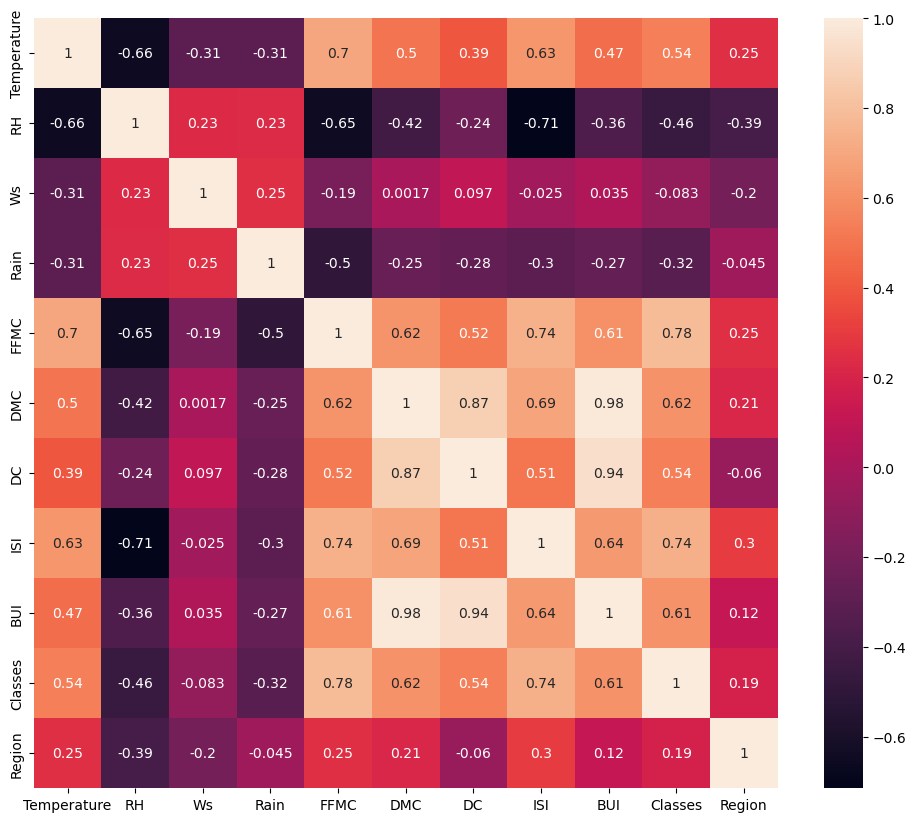

In [38]:
plt.figure(figsize=(12,10))
sns.heatmap(x_train.corr(),annot=True)

In [39]:
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold :
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [40]:
correlation(x_train,0.90)

{'BUI'}

In [41]:
# threshold--DOmain Expert
corr_features=correlation(x_train,0.85)
corr_features


{'BUI', 'DC'}

In [42]:
x_train.drop(corr_features,axis=1,inplace=True)
x_test.drop(corr_features,axis=1,inplace=True)
x_train.shape,x_test.shape

((182, 9), (61, 9))

In [43]:
x_train

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
97,29,74,19,0.0,75.0,3.0,2.0,0,0
141,31,72,14,0.0,60.0,3.0,0.0,0,1
192,40,31,15,0.0,94.0,22.0,16.0,1,1
68,32,60,18,0.0,77.0,11.0,2.0,0,0
119,32,47,14,0.0,77.0,7.0,1.0,0,0
...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.0,44.0,0.0,0.0,0,0
14,28,80,17,3.0,49.0,3.0,0.0,0,0
92,25,76,17,7.0,46.0,1.0,0.0,0,0
179,34,59,16,0.0,88.0,19.0,7.0,1,1


In [45]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [47]:
x_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.5579568 ,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -1.02164693,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.6878741 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.02164693,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.60126852,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.78980187,
        -1.10431526, -0.98907071]])

##  box plotting to understand the effect of scaling


Text(0.5, 1.0, 'Data after Scaling')

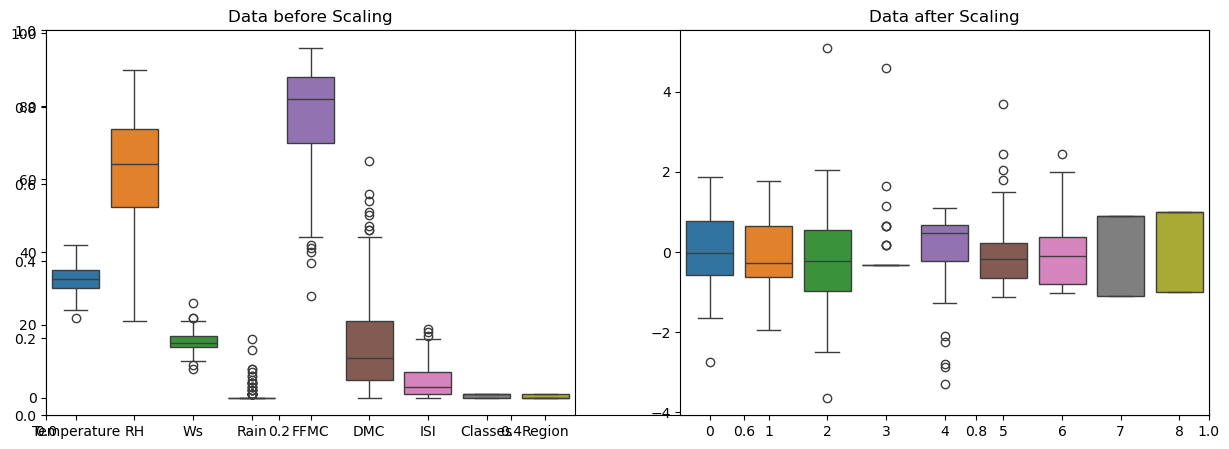

In [61]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title('Data before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=x_test_scaled)
plt.title('Data after Scaling')


## Linear Regression

Mean absolute Error: 0.6513439558787265
R2 score: 0.9806173849583818


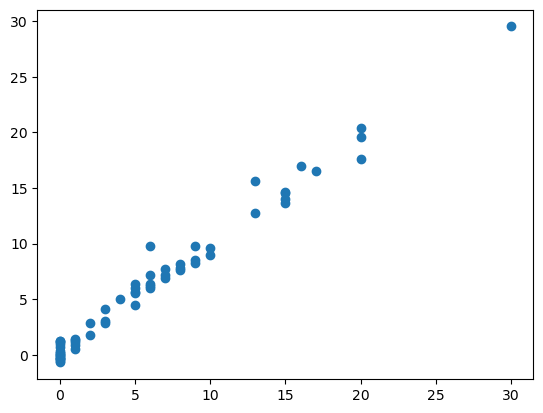

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error
linreg=LinearRegression()
linreg.fit(x_train_scaled,y_train)
y_pred=linreg.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean absolute Error:", mae)
print("R2 score:",r2)
plt.scatter(y_test,y_pred)

## Lasso Regression

Mean absolute Error: 1.2585075887813455
R2 score: 0.942087324522286


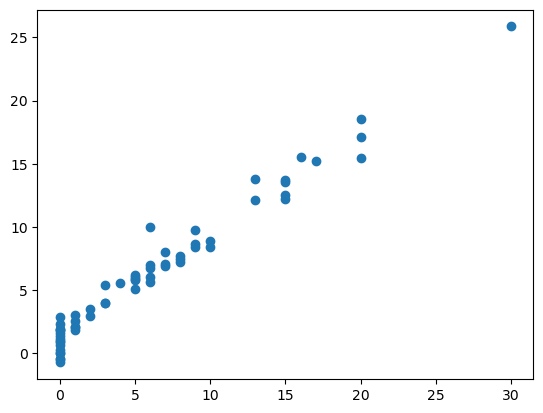

In [67]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score,mean_absolute_error
lasso=Lasso()
lasso.fit(x_train_scaled,y_train)
y_pred=lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean absolute Error:", mae)
print("R2 score:",r2)
plt.scatter(y_test,y_pred)

## ride regression

Mean absolute Error: 0.6583310952992616
R2 score: 0.9802774276038305


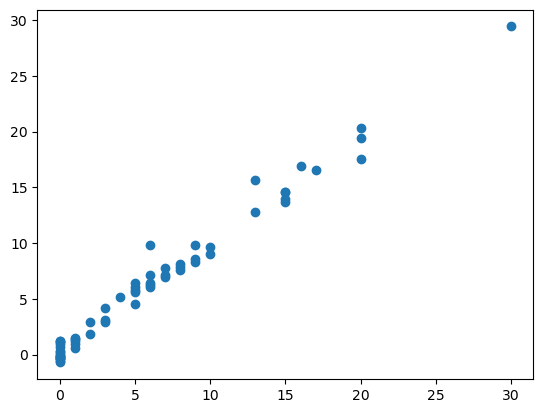

In [68]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score,mean_absolute_error
ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean absolute Error:", mae)
print("R2 score:",r2)
plt.scatter(y_test,y_pred)

## Elastic net regression

Mean absolute Error: 1.93667438359563
R2 score: 0.8716490544669823


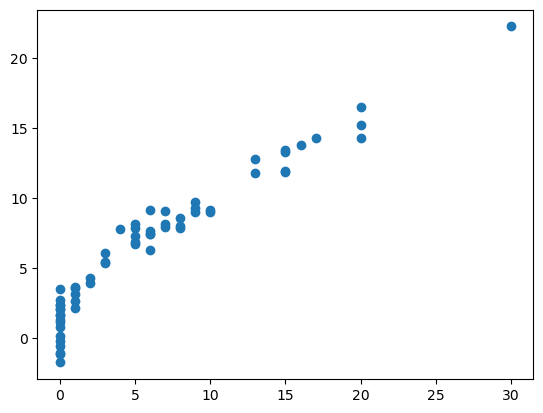

In [69]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score,mean_absolute_error
elastic=ElasticNet()
elastic.fit(x_train_scaled,y_train)
y_pred=elastic.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean absolute Error:", mae)
print("R2 score:",r2)
plt.scatter(y_test,y_pred)

# Cross Validation

## lasso Cross Validation

Mean absolute Error: 0.7039036844128209
R2 score: 0.9781302562168812


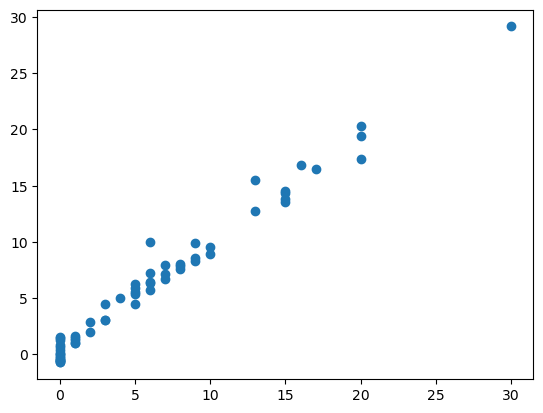

In [70]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score,mean_absolute_error
lassocv=LassoCV(cv=5)
lassocv.fit(x_train_scaled,y_train)
y_pred=lassocv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean absolute Error:", mae)
print("R2 score:",r2)
plt.scatter(y_test,y_pred)

In [72]:
lassocv.alpha_

np.float64(0.04961249024508133)

In [73]:
lassocv.alphas_

array([7.03244231, 6.55847923, 6.11645968, 5.70423077, 5.31978471,
       4.96124902, 4.62687744, 4.31504139, 4.02422204, 3.75300295,
       3.50006311, 3.26417057, 3.0441764 , 2.8390091 , 2.64766939,
       2.46922533, 2.30280781, 2.14760627, 2.00286479, 1.86787841,
       1.74198966, 1.62458538, 1.51509377, 1.41298152, 1.31775129,
       1.22893927, 1.14611287, 1.0688687 , 0.99683053, 0.92964749,
       0.86699236, 0.80855997, 0.75406574, 0.70324423, 0.65584792,
       0.61164597, 0.57042308, 0.53197847, 0.4961249 , 0.46268774,
       0.43150414, 0.4024222 , 0.37530029, 0.35000631, 0.32641706,
       0.30441764, 0.28390091, 0.26476694, 0.24692253, 0.23028078,
       0.21476063, 0.20028648, 0.18678784, 0.17419897, 0.16245854,
       0.15150938, 0.14129815, 0.13177513, 0.12289393, 0.11461129,
       0.10688687, 0.09968305, 0.09296475, 0.08669924, 0.080856  ,
       0.07540657, 0.07032442, 0.06558479, 0.0611646 , 0.05704231,
       0.05319785, 0.04961249, 0.04626877, 0.04315041, 0.04024

## ridge cross validation

Mean absolute Error: 0.8287353801581359
R2 score: 0.9739736356166706


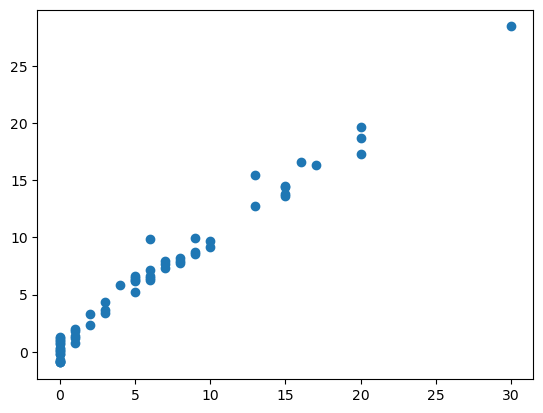

In [74]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score,mean_absolute_error
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train_scaled,y_train)
y_pred=ridgecv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean absolute Error:", mae)
print("R2 score:",r2)
plt.scatter(y_test,y_pred)

In [80]:
ridgecv.alphas

(0.1, 1.0, 10.0)

In [82]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

## elastic net cross validation

Mean absolute Error: 0.7369707489656091
R2 score: 0.9773360327851938


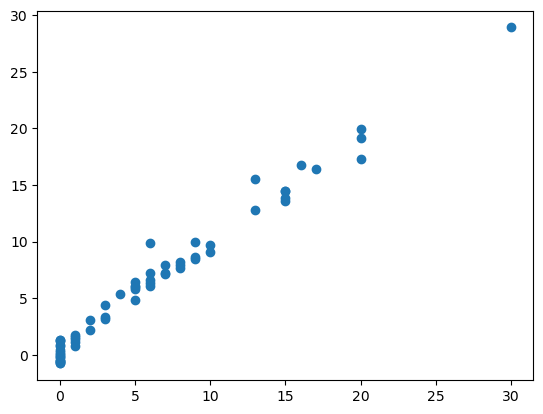

In [77]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score,mean_absolute_error
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(x_train_scaled,y_train)
y_pred=elasticcv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean absolute Error:", mae)
print("R2 score:",r2)
plt.scatter(y_test,y_pred)

In [79]:
elasticcv.alphas

## pickle the ml model ,preprocessing model standardscaler

In [84]:
scaler


StandardScaler()

In [85]:
ridge

Ridge()

In [86]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))